# Assignment

> Add blockquote



## Problem Statement:
Study analysis on the public sentiment towards a company and its stock effect their prices by extracting opinions from Twitter in determining whether public opinion has impact on the stock prices of the company.

In [1]:
import pandas as pd
import numpy as np

path = "dataset.csv"
df = pd.read_csv(path)

# Creating a small sample for faster processing during the notebook
# df = df.head(100000).copy()

print(f"Using sample size: {len(df):,}")
print(df.head())

Using sample size: 1,395,450
  Unnamed: 0                                              TWEET       STOCK  \
0          0  RT @robertoglezcano: @amazon  #Patents Show Fl...         NaN   
1        NaN                                             Amazon  31/01/2017   
2          1  @FAME95FM1 Jamaicans make money with @Payoneer...      PayPal   
3          2  @CBSi Jamaicans make money with @Payoneer @Pay...      PayPal   
4          3  @Hitz92fm Jamaicans make money with @Payoneer ...      PayPal   

         DATE  LAST_PRICE  1_DAY_RETURN  2_DAY_RETURN  3_DAY_RETURN  \
0         NaN         NaN           NaN           NaN           NaN   
1      823.48    0.008379      0.014924      0.014924     -0.001263   
2  31/01/2017   39.780000      0.002011      0.012318      0.012318   
3  31/01/2017   39.780000      0.002011      0.012318      0.012318   
4  31/01/2017   39.780000      0.002011      0.012318      0.012318   

   7_DAY_RETURN    PX_VOLUME  VOLATILITY_10D  VOLATILITY_30D  LSTM_PO

C:\Users\hafiz\AppData\Local\Temp\ipykernel_24756\2615617578.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


### Basic Descriptive Statistics

In [2]:
print("Describe: ", df.describe())

Describe:            LAST_PRICE   1_DAY_RETURN   2_DAY_RETURN  3_DAY_RETURN  \
count  862231.000000  862231.000000  862231.000000  8.622310e+05   
mean      716.123477       0.001473       0.002579  3.262616e+06   
std      4731.498118       0.023068       0.032594  1.053913e+07   
min        -0.173554      -0.177851      -0.204959 -2.049587e-01   
25%         0.000000      -0.007511      -0.011456 -8.465608e-03   
50%         0.014220       0.000000       0.000000  1.019542e-02   
75%       115.600000       0.008192       0.013911  6.545426e-02   
max    165500.000000       0.243639       0.267113  3.081068e+08   

       7_DAY_RETURN     PX_VOLUME  VOLATILITY_10D  VOLATILITY_30D  \
count  8.622310e+05  8.622310e+05   862130.000000   862184.000000   
mean   6.201036e+06  7.522187e+06       18.293836       10.738204   
std    1.388221e+07  1.591847e+07       16.277630       14.693986   
min   -2.049587e-01  1.000000e+00       -1.000000       -1.000000   
25%    5.474453e-03  2.051700e+

In [3]:
df.isnull().sum()

Unnamed: 0            293437
TWEET                     52
STOCK                 533219
DATE                  533219
LAST_PRICE            533219
1_DAY_RETURN          533219
2_DAY_RETURN          533219
3_DAY_RETURN          533219
7_DAY_RETURN          533219
PX_VOLUME             533219
VOLATILITY_10D        533320
VOLATILITY_30D        533266
LSTM_POLARITY         734348
TEXTBLOB_POLARITY    1027785
dtype: int64

In [4]:
df = df.dropna(subset="TWEET")
df.isnull().sum()

Unnamed: 0            293437
TWEET                      0
STOCK                 533167
DATE                  533167
LAST_PRICE            533167
1_DAY_RETURN          533167
2_DAY_RETURN          533167
3_DAY_RETURN          533167
7_DAY_RETURN          533167
PX_VOLUME             533167
VOLATILITY_10D        533268
VOLATILITY_30D        533214
LSTM_POLARITY         734296
TEXTBLOB_POLARITY    1027733
dtype: int64

In [5]:
print(df['LSTM_POLARITY'].unique())
print(df['TEXTBLOB_POLARITY'].unique())

[        nan  0.         -1.         ... -0.15277778  0.50729167
  0.55885417]
[        nan  0.          0.2        ...  0.67708333  0.23111111
 -0.12797619]


In [6]:
lstm_counts = df['LSTM_POLARITY'].value_counts()
textblob_counts = df['TEXTBLOB_POLARITY'].value_counts()

print("LSTM Distribution:\n", lstm_counts)
print("\nTextBlob Distribution:\n", textblob_counts)

LSTM Distribution:
 LSTM_POLARITY
 1.000000    209836
-1.000000    162613
 0.000000    154342
 0.136364     21340
 0.500000      9469
              ...  
 0.237143         1
-0.857143         1
 0.047273         1
-0.022321         1
 0.568750         1
Name: count, Length: 2775, dtype: int64

TextBlob Distribution:
 TEXTBLOB_POLARITY
 0.000000    191878
 0.500000     14745
 0.250000      8104
 0.200000      7812
 0.136364      7630
              ...  
-0.067708         1
-0.520833         1
 0.141026         1
-0.012698         1
 0.161538         1
Name: count, Length: 3375, dtype: int64


In [7]:
import sys
print(sys.executable)

c:\Users\hafiz\AppData\Local\Programs\Python\Python313\python.exe


In [8]:
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


LSTM_sentiment
Neutral     888638
Positive    307431
Negative    199329
Name: count, dtype: int64


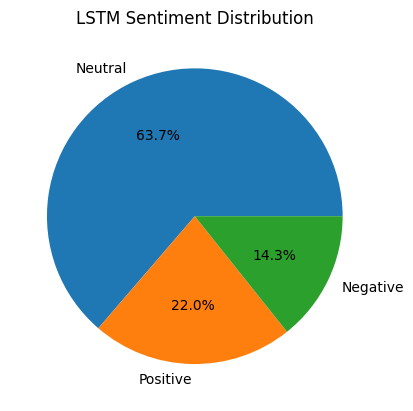

In [9]:
def categorize_lstm(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['LSTM_sentiment'] = df['LSTM_POLARITY'].apply(categorize_lstm)

lstm_counts = df['LSTM_sentiment'].value_counts()
print(lstm_counts)

import matplotlib.pyplot as plt

plt.figure()
plt.pie(lstm_counts, labels=lstm_counts.index, autopct='%1.1f%%')
plt.title("LSTM Sentiment Distribution")
plt.show()

### Metada Analysis

In [10]:
#if sentiment analysis has more neutral than +ve & -ve, there is issue in dataset
print(df.columns)
print(df['STOCK'].value_counts())


Index(['Unnamed: 0', 'TWEET', 'STOCK', 'DATE', 'LAST_PRICE', '1_DAY_RETURN',
       '2_DAY_RETURN', '3_DAY_RETURN', '7_DAY_RETURN', 'PX_VOLUME',
       'VOLATILITY_10D', 'VOLATILITY_30D', 'LSTM_POLARITY',
       'TEXTBLOB_POLARITY', 'LSTM_sentiment'],
      dtype='object')
STOCK
Ford        52198
Facebook    40837
Google      33697
Next        32606
Apple       27940
            ...  
33.3            1
536.9           1
15.61           1
5468.0          1
1028.0          1
Name: count, Length: 4241, dtype: int64


In [11]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df['cleaned_tweet'] = df['TWEET'].apply(clean_text)

In [12]:
!{sys.executable} -m pip install nltk


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
### Remove Stopword
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from collections import Counter

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return words

all_words = []

for tweet in df['TWEET']:
    all_words.extend(clean_text(tweet))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
word_counts = Counter(all_words)
top_words = word_counts.most_common(15)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

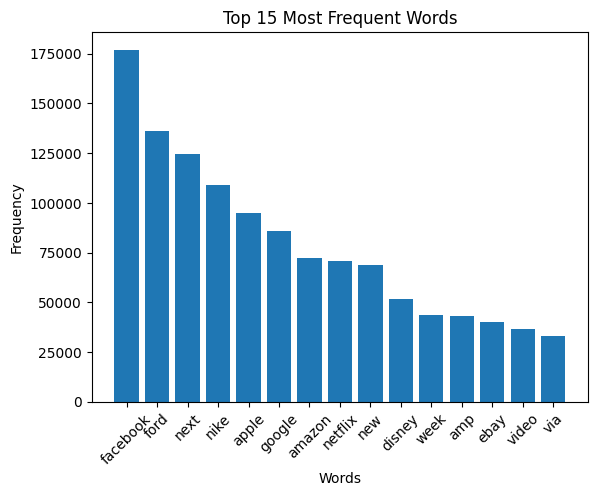

In [15]:
### Plotting
import matplotlib.pyplot as plt

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 15 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [16]:
from textblob import TextBlob

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

df['calculated_polarity'] = df['TWEET'].apply(get_polarity)

In [17]:
def categorize_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['calculated_polarity'].apply(categorize_sentiment)

In [18]:
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

sentiment
Neutral     918481
Positive    342309
Negative    134608
Name: count, dtype: int64


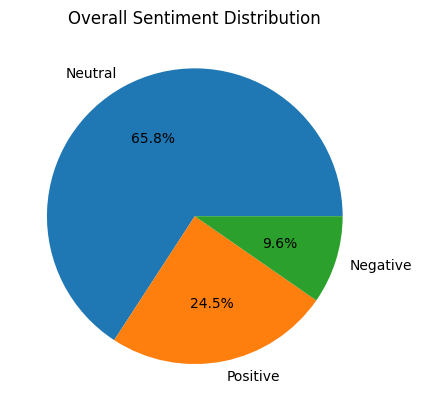

In [19]:
plt.figure()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title("Overall Sentiment Distribution")
plt.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


vader_sentiment
Neutral     857457
Positive    339927
Negative    198014
Name: count, dtype: int64


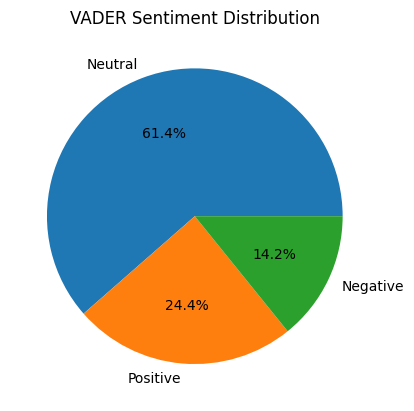

In [20]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df['vader_sentiment'] = df['TWEET'].apply(get_sentiment)

vader_counts = df['vader_sentiment'].value_counts()
print(vader_counts)

import matplotlib.pyplot as plt

plt.figure()
plt.pie(vader_counts, labels=vader_counts.index, autopct='%1.1f%%')
plt.title("VADER Sentiment Distribution")
plt.show()

### Preprocessing Pipeline

#### Sentence Segmentation

In [21]:
import nltk

from nltk.tokenize import sent_tokenize

# Download the required NLTK resources
nltk.download('punkt')      # Rules for tokenization (chopping text)
nltk.download('punkt_tab')  # NEW requirement for tokenization in updated NLTK versions
nltk.download('stopwords')  # List of common, uninformative words
nltk.download('wordnet')    # Massive English dictionary for Lemmatization
nltk.download('omw-1.4')    # Supporting data for WordNet

print("NLTK Resources Downloaded Successfully!")


NLTK Resources Downloaded Successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [22]:

# Sentence Segmentation
df["sentences"] = df["TWEET"].apply(sent_tokenize)



In [23]:
for i, s in enumerate(df["sentences"].iloc[194]):
    print(f"Sentence {i+1}: {s}")

Sentence 1: RT @cultcommoncore: Dumping @Starbucks
Is like dropping cable tv.
Sentence 2: You wonder how you paid 
SO much
For such crap
For SO long.…


#### Handling Abbreviations

In [24]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

In [25]:
# Abbreviation Dictionary
abbreviation_dict = {
    "rt": "retweet",
    "roi": "return on investment",
    "vix": "volatility index",
    "u": "you",
    "ur": "your",
    "w/": "with",
    "dm": "direct message",
    "fb": "facebook",
    "ig": "instagram",
    "li": "linkedin",
    "yt": "youtube",
    "omg": "oh my god",
    "lol": "laugh out loud"
}

#### Tokenization

In [26]:
def tokenize_and_clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    tokens = word_tokenize(text)

    expanded_tokens = []
    for word in tokens:
        expanded_word = abbreviation_dict.get(word, word)
        expanded_tokens.extend(expanded_word.split())

    clean_tokens = [word for word in expanded_tokens if word.isalpha()]
    return clean_tokens

In [27]:
def expand_abbreviations(token_list):
  expanded_tokens = []
  for word in token_list:
    # if word in dict, replace it
    expanded_word = abbreviation_dict.get(word.lower(), word)
    expanded_tokens.append(expanded_word.split())
  return expanded_tokens

df["tokens"] = df["TWEET"].apply(tokenize_and_clean)
df["expanded_tokens"] = df["tokens"].apply(expand_abbreviations)

In [28]:
df['expanded_tokens']

0          [[retweet], [robertoglezcano], [amazon], [pate...
1                                                 [[amazon]]
2          [[jamaicans], [make], [money], [with], [payone...
3          [[cbsi], [jamaicans], [make], [money], [with],...
4          [[jamaicans], [make], [money], [with], [payone...
                                 ...                        
1395445                                           [[paypal]]
1395446    [[retweet], [rifatjawaid], [deceased], [apple]...
1395447                                            [[apple]]
1395448    [[flat], [inr], [cashback], [on], [hdfc], [deb...
1395449                                          [[samsung]]
Name: expanded_tokens, Length: 1395398, dtype: object

#### Stopword Removal

In [29]:
from nltk.corpus import stopwords

# Load the English stopwords list
stop_words = set(stopwords.words('english'))

# We can also add custom stopwords specific to our dataset if we want
custom_stopwords = ['next', 'via', 'amp']
stop_words.update(custom_stopwords)

def remove_stopwords(token_list):
    # Keep the word ONLY if it is not in our stop_words list
    filtered_tokens = [word for word in token_list if word not in stop_words]
    return filtered_tokens

# Apply to our tokens
df['filtered_tokens'] = df['tokens'].apply(remove_stopwords)

# Compare the tokens before and after stopword removal
df[['tokens', 'filtered_tokens']].head()

,tokens,filtered_tokens
0,"[retweet, robertoglezcano, amazon, patents, sh...","[retweet, robertoglezcano, amazon, patents, sh..."
1,[amazon],[amazon]
2,"[jamaicans, make, money, with, payoneer, paypa...","[jamaicans, make, money, payoneer, paypal, pax..."
3,"[cbsi, jamaicans, make, money, with, payoneer,...","[cbsi, jamaicans, make, money, payoneer, paypa..."
4,"[jamaicans, make, money, with, payoneer, paypa...","[jamaicans, make, money, payoneer, paypal, pax..."


#### Stemming or Lemmatization

In [30]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Initialize our two tools
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def apply_stemming(token_list):
    return [stemmer.stem(word) for word in token_list]

def apply_lemmatization(token_list):
    return [lemmatizer.lemmatize(word) for word in token_list]

# Create two new columns to compare the results
df['stemmed_words'] = df['filtered_tokens'].apply(apply_stemming)
df['lemmatized_words'] = df['filtered_tokens'].apply(apply_lemmatization)

print("Stemming and Lemmatization complete!")

Stemming and Lemmatization complete!


#### POS Tagging

In [31]:
nltk.download('averaged_perceptron_tagger_eng')


#apply pos tag
df['pos_tags'] = df['lemmatized_words'].apply(nltk.pos_tag)



[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Named Entity Recognition (NER)

In [32]:
# nltk.download('maxent_ne_chunker_tab')
# nltk.download('words')

# def apply_ner(tagged_tokens):
#   return nltk.ne_chunk(tagged_tokens)

# df['ner'] = df['pos_tags'].apply(apply_ner)

#### Word Cloud Visualization

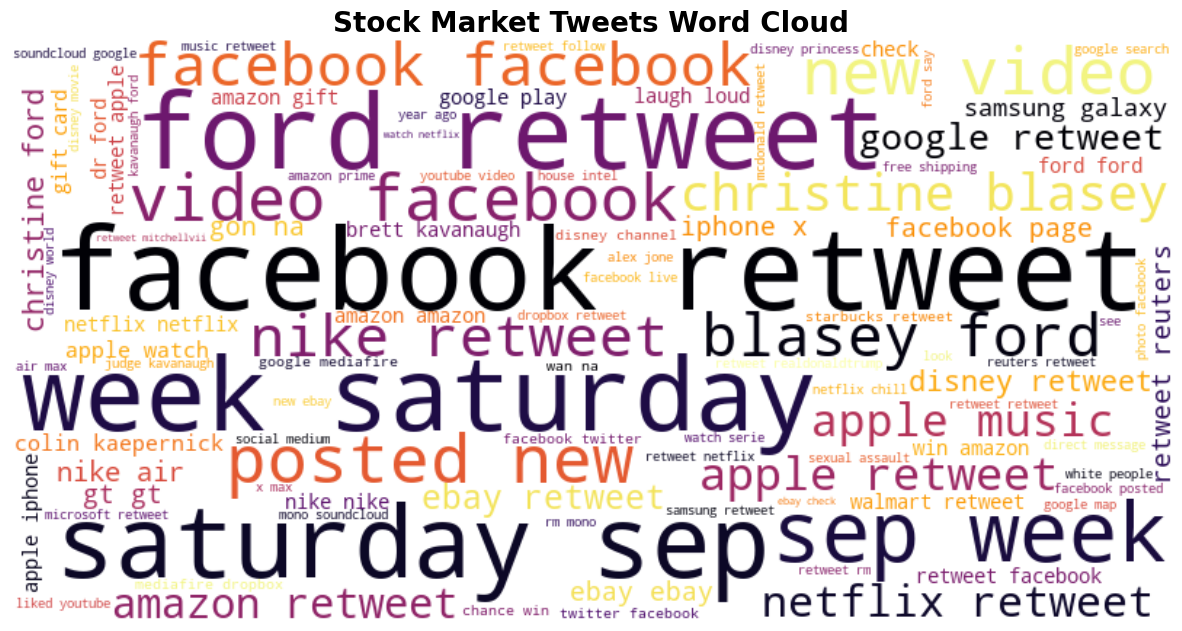

In [33]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_clean_words = []
for word_list in df['lemmatized_words']:
    all_clean_words.extend(word_list)

text_for_cloud = " ".join(all_clean_words)

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='inferno',
                      max_words=100).generate(text_for_cloud)

# Plot the image
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Turn off the grid numbers
plt.title("Stock Market Tweets Word Cloud", fontsize=20, fontweight='bold')
plt.show()

pipeline comparison

In [34]:
# Select a random row (e.g., row index 5) to inspect
row_to_inspect = 200

print("1. ORIGINAL TEXT:")
print(df['TWEET'].iloc[row_to_inspect])
print("\n2. TOKENIZED & NOISE REMOVED:")
print(df['tokens'].iloc[row_to_inspect])
print("\n3. STOPWORDS REMOVED:")
print(df['filtered_tokens'].iloc[row_to_inspect])
print("\n4. STEMMED (Chopped endings):")
print(df['stemmed_words'].iloc[row_to_inspect])
print("\n5. LEMMATIZED (Dictionary root):")
print(df['lemmatized_words'].iloc[row_to_inspect])

1. ORIGINAL TEXT:
eBay

2. TOKENIZED & NOISE REMOVED:
['ebay']

3. STOPWORDS REMOVED:
['ebay']

4. STEMMED (Chopped endings):
['ebay']

5. LEMMATIZED (Dictionary root):
['ebay']


In [36]:
!{sys.executable} -m pip install scikit-learn seaborn afinn

import seaborn as sns
from afinn import Afinn
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

def get_sentiment_class(score, positive_threshold=0, negative_threshold=0):
    if score > positive_threshold:
        return 'Positive'
    elif score < negative_threshold:
        return 'Negative'
    return 'Neutral'

# Reuse lemmatized words when available so TF-IDF works on cleaner tokens.
if 'lemmatized_words' in df.columns:
    df['joined_tokens'] = df['lemmatized_words'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')
else:
    df['joined_tokens'] = df['TWEET'].fillna('').astype(str)

# TextBlob comparison column
df['textblob_polarity'] = df['joined_tokens'].apply(lambda text: TextBlob(text).sentiment.polarity)
df['textblob_sentiment'] = df['textblob_polarity'].apply(get_sentiment_class)

# VADER comparison column
sia = SentimentIntensityAnalyzer()
df['vader_score'] = df['TWEET'].fillna('').astype(str).apply(lambda text: sia.polarity_scores(text)['compound'])
df['vader_sentiment'] = df['vader_score'].apply(lambda score: get_sentiment_class(score, 0.05, -0.05))

# AFINN comparison column
afinn = Afinn()
df['afinn_score'] = df['joined_tokens'].apply(afinn.score)
df['afinn_sentiment'] = df['afinn_score'].apply(get_sentiment_class)

# Use the existing LSTM polarity labels to define sentiment groups for TF-IDF.
if 'LSTM_sentiment' not in df.columns and 'LSTM_POLARITY' in df.columns:
    df['LSTM_sentiment'] = df['LSTM_POLARITY'].apply(get_sentiment_class)

tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df['joined_tokens'])
feature_names = tfidf_vectorizer.get_feature_names_out()
# Ensure the TF-IDF DataFrame uses the same index as the original df so .loc with df indices works
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names, index=df.index)

sentiment_order = ['Negative', 'Neutral', 'Positive']
sentiment_columns = ['textblob_sentiment', 'vader_sentiment', 'afinn_sentiment']
sentiment_summary = pd.DataFrame({
    'TextBlob': df['textblob_sentiment'].value_counts(),
    'VADER': df['vader_sentiment'].value_counts(),
    'AFINN': df['afinn_sentiment'].value_counts(),
}).reindex(sentiment_order).fillna(0).astype(int)

tfidf_group_column = 'LSTM_sentiment' if 'LSTM_sentiment' in df.columns else 'vader_sentiment'
tfidf_top_terms = {}
for sentiment in sentiment_order:
    group_index = df.index[df[tfidf_group_column] == sentiment]
    if len(group_index) == 0:
        tfidf_top_terms[sentiment] = pd.Series(dtype=float)
        continue

    mean_scores = df_tfidf.loc[group_index].mean().sort_values(ascending=False).head(10)
    tfidf_top_terms[sentiment] = mean_scores

comparison_table = df[[
    'TWEET', 'textblob_sentiment', 'vader_sentiment', 'afinn_sentiment'
]].head(15)

print('--- Sentiment Comparison Counts ---')
display(sentiment_summary)
print('\n--- Sample Tweet-Level Comparison ---')
display(comparison_table)



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


--- Sentiment Comparison Counts ---


,TextBlob,VADER,AFINN
Negative,128138,198014,198165
Neutral,939524,857457,919005
Positive,327736,339927,278228



--- Sample Tweet-Level Comparison ---


,TWEET,textblob_sentiment,vader_sentiment,afinn_sentiment
0,RT @robertoglezcano: @amazon #Patents Show Fl...,Neutral,Neutral,Neutral
1,Amazon,Neutral,Positive,Neutral
2,@FAME95FM1 Jamaicans make money with @Payoneer...,Neutral,Neutral,Neutral
3,@CBSi Jamaicans make money with @Payoneer @Pay...,Neutral,Neutral,Neutral
4,@Hitz92fm Jamaicans make money with @Payoneer ...,Neutral,Neutral,Neutral
5,RT @loadsofvans: Retweet this post &amp; follo...,Positive,Positive,Positive
6,Amazon,Neutral,Positive,Neutral
7,RT @Disney: See The Newest Trailer for #Beauty...,Neutral,Neutral,Neutral
8,Disney,Neutral,Neutral,Neutral
9,RT @tarastrong: Just got @facebook back! I REA...,Positive,Positive,Positive


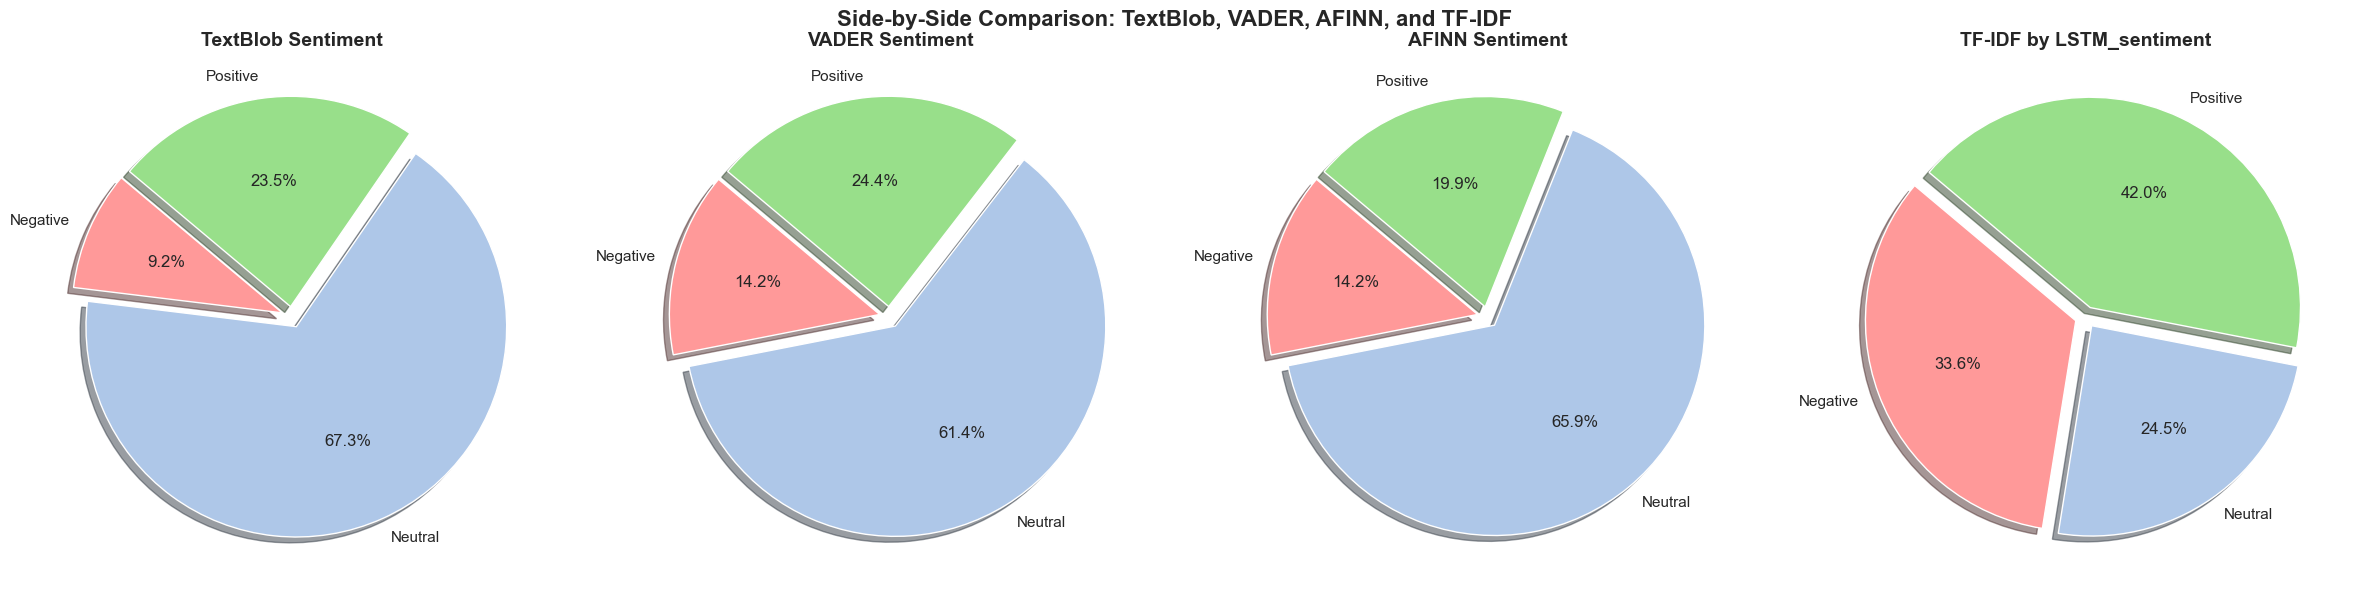

--- TF-IDF Top Terms by Sentiment Group ---


,Negative,Neutral,Positive
0,retweet (0.080),retweet (0.051),facebook (0.099)
1,ford (0.056),facebook (0.049),retweet (0.076)
2,facebook (0.051),ford (0.037),ford (0.059)
3,nike (0.048),nike (0.034),nike (0.041)
4,apple (0.035),apple (0.028),apple (0.039)
5,google (0.035),netflix (0.025),google (0.035)
6,netflix (0.025),google (0.024),amazon (0.033)
7,amazon (0.024),new (0.022),disney (0.028)
8,disney (0.014),week (0.022),netflix (0.028)
9,ebay (0.013),amazon (0.021),ebay (0.016)


In [37]:
sns.set_theme(style='whitegrid')
pie_palette = ['#ff9999', '#aec7e8', '#98df8a']
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

method_columns = [
    ('TextBlob', 'textblob_sentiment'),
    ('VADER', 'vader_sentiment'),
    ('AFINN', 'afinn_sentiment'),
]

for ax, (method_name, column_name) in zip(axes[:3], method_columns):
    counts = df[column_name].value_counts().reindex(sentiment_order).fillna(0)
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=pie_palette,
        explode=(0.05, 0.05, 0.05),
        shadow=True,
    )
    ax.set_title(f'{method_name} Sentiment', fontsize=14, fontweight='bold')

tfidf_sentiment_strength = pd.Series({
    sentiment: tfidf_top_terms[sentiment].head(3).sum()
    for sentiment in sentiment_order
}).reindex(sentiment_order).fillna(0)

if tfidf_sentiment_strength.sum() > 0:
    axes[3].pie(
        tfidf_sentiment_strength,
        labels=tfidf_sentiment_strength.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=pie_palette,
        explode=(0.05, 0.05, 0.05),
        shadow=True,
    )
    axes[3].set_title(f'TF-IDF by {tfidf_group_column}', fontsize=14, fontweight='bold')
else:
    axes[3].set_title(f'TF-IDF by {tfidf_group_column}', fontsize=14, fontweight='bold')
    axes[3].text(0.5, 0.5, 'No TF-IDF data', ha='center', va='center')
    axes[3].axis('off')

plt.suptitle('Side-by-Side Comparison: TextBlob, VADER, AFINN, and TF-IDF', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

tfidf_summary_table = pd.concat({
    sentiment: pd.Series([f"{term} ({score:.3f})" for term, score in tfidf_top_terms[sentiment].items()])
    for sentiment in ['Negative', 'Neutral', 'Positive']
}, axis=1)

print('--- TF-IDF Top Terms by Sentiment Group ---')
display(tfidf_summary_table)


## W9 Continuation: Document and Sentence Level Opinion Mining

This continuation adapts the Week 9 workflow into the assignment notebook using the existing `df` dataframe and the local `TWEET` column instead of the original Google Colab dataset.


In [46]:
# --- W9 Step 1: Local Setup and Dataset Preparation ---

import json
import nltk
import pandas as pd
import numpy as np

nltk.download('punkt', quiet=True)
nltk.download('vader_lexicon', quiet=True)

df_w9 = df[['TWEET', 'STOCK']].copy()
df_w9['TWEET'] = df_w9['TWEET'].fillna('').astype(str).str.strip()
df_w9 = df_w9[df_w9['TWEET'] != ''].copy()

# sample_size = min(15000, len(df_w9))
df_w9 = df_w9.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'W9 continuation dataset ready: {len(df_w9):,} tweets selected for benchmarking.')
df_w9[['STOCK', 'TWEET']].head(3)


W9 continuation dataset ready: 1,395,398 tweets selected for benchmarking.


,STOCK,TWEET
0,Nike,RT @stardazzledd: Nike Windbreakers 💝\r\r\r\r\...
1,Facebook,RT @RTAluvzAfridi: It’s all over Facebook. Twi...
2,Google,RT @warriors: “You are so much more than what ...


### Ground Truth Construction and TF-IDF Benchmarking

Following the W9 notebook, we create three sentiment classes using keyword-based rules, then compare a TF-IDF + SVM model against VADER on the same test split.


In [47]:
# --- W9 Step 2: Build 3-Class Labels and Train TF-IDF + SVM ---

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

tweet_text = df_w9['TWEET'].str.lower()
conditions = [
    tweet_text.str.contains('loss|bearish|drop|crash|fear|risk|lawsuit|panic|fall|bad', na=False),
    tweet_text.str.contains('gain|bullish|surge|profit|growth|recovery|strong|buy|good|great', na=False),
]
choices = [0, 2]  # 0 = Negative, 2 = Positive
df_w9['Ground_Truth'] = np.select(conditions, choices, default=1)

label_counts = pd.Series(df_w9['Ground_Truth']).value_counts()
stratify_labels = df_w9['Ground_Truth'] if label_counts.min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    df_w9['TWEET'],
    df_w9['Ground_Truth'],
    test_size=0.20,
    random_state=42,
    stratify=stratify_labels
)

tfidf_vectorizer_w9 = TfidfVectorizer(max_features=2500, stop_words='english')
X_train_tfidf = tfidf_vectorizer_w9.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer_w9.transform(X_test)

svm_model_w9 = LinearSVC(random_state=42)
svm_model_w9.fit(X_train_tfidf, y_train)
svm_predictions_w9 = svm_model_w9.predict(X_test_tfidf)

print('Three-class TF-IDF + SVM model trained successfully.')
print(pd.Series(df_w9['Ground_Truth']).value_counts().rename({0: 'Negative', 1: 'Neutral', 2: 'Positive'}))


Three-class TF-IDF + SVM model trained successfully.
Ground_Truth
Neutral     1319859
Positive      51261
Negative      24278
Name: count, dtype: int64


c:\Users\hafiz\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [48]:
# --- W9 Step 3: Generate VADER Predictions on the Same Test Split ---

from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia_w9 = SentimentIntensityAnalyzer()
vader_predictions_w9 = []

for tweet in X_test.astype(str):
    compound = sia_w9.polarity_scores(tweet)['compound']
    if compound <= -0.05:
        vader_predictions_w9.append(0)
    elif compound >= 0.05:
        vader_predictions_w9.append(2)
    else:
        vader_predictions_w9.append(1)

print('VADER predictions generated for the Week 9 benchmark split.')


VADER predictions generated for the Week 9 benchmark split.


VADER Classification Report
              precision    recall  f1-score   support

    Negative       0.05      0.41      0.09      4856
     Neutral       0.98      0.64      0.77    263972
    Positive       0.09      0.61      0.16     10252

    accuracy                           0.63    279080
   macro avg       0.37      0.55      0.34    279080
weighted avg       0.93      0.63      0.74    279080

TF-IDF + SVM Classification Report
              precision    recall  f1-score   support

    Negative       1.00      0.66      0.80      4856
     Neutral       0.98      1.00      0.99    263972
    Positive       0.99      0.66      0.79     10252

    accuracy                           0.98    279080
   macro avg       0.99      0.77      0.86    279080
weighted avg       0.98      0.98      0.98    279080



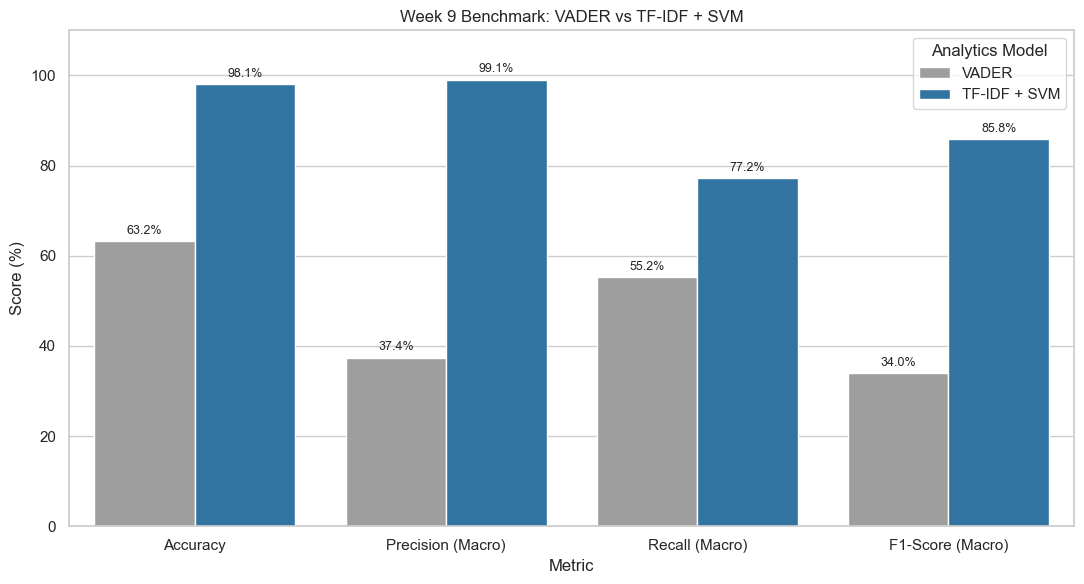

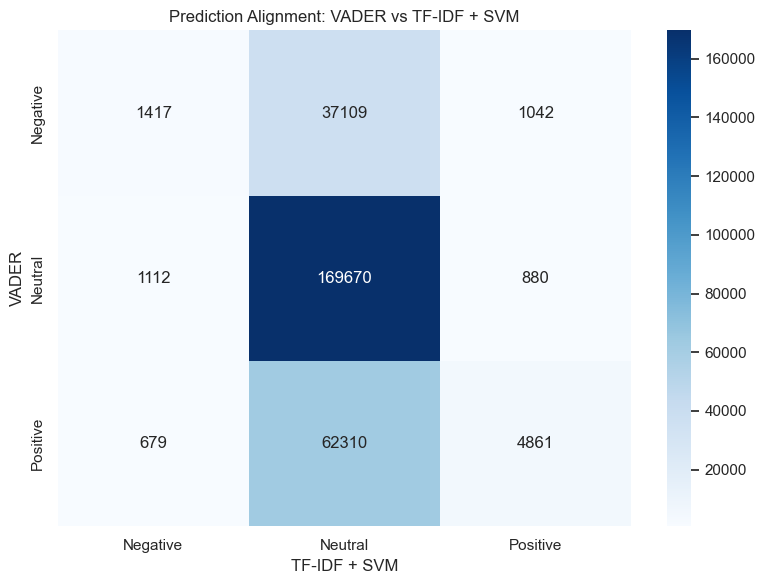

Accuracy comparison -> VADER: 63.21% | TF-IDF + SVM: 98.14%


In [49]:
# --- W9 Step 4: Evaluation Reports and Comparative Visualizations ---

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

class_names_w9 = ['Negative', 'Neutral', 'Positive']

print('VADER Classification Report')
print(classification_report(y_test, vader_predictions_w9, target_names=class_names_w9, labels=[0, 1, 2]))
print('TF-IDF + SVM Classification Report')
print(classification_report(y_test, svm_predictions_w9, target_names=class_names_w9, labels=[0, 1, 2]))

vader_metrics_w9 = precision_recall_fscore_support(y_test, vader_predictions_w9, average='macro', zero_division=0)
svm_metrics_w9 = precision_recall_fscore_support(y_test, svm_predictions_w9, average='macro', zero_division=0)
vader_acc_w9 = accuracy_score(y_test, vader_predictions_w9)
svm_acc_w9 = accuracy_score(y_test, svm_predictions_w9)

df_perf_w9 = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'] * 2,
    'Score (%)': [
        vader_acc_w9 * 100, vader_metrics_w9[0] * 100, vader_metrics_w9[1] * 100, vader_metrics_w9[2] * 100,
        svm_acc_w9 * 100, svm_metrics_w9[0] * 100, svm_metrics_w9[1] * 100, svm_metrics_w9[2] * 100
    ],
    'Analytics Model': ['VADER'] * 4 + ['TF-IDF + SVM'] * 4
})

plt.figure(figsize=(11, 6))
sns.set_theme(style='whitegrid')
ax = sns.barplot(data=df_perf_w9, x='Metric', y='Score (%)', hue='Analytics Model', palette=['#9e9e9e', '#1f77b4'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)
plt.title('Week 9 Benchmark: VADER vs TF-IDF + SVM')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
cm_comparison_w9 = confusion_matrix(vader_predictions_w9, svm_predictions_w9, labels=[0, 1, 2])
sns.heatmap(cm_comparison_w9, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_w9, yticklabels=class_names_w9)
plt.title('Prediction Alignment: VADER vs TF-IDF + SVM')
plt.xlabel('TF-IDF + SVM')
plt.ylabel('VADER')
plt.tight_layout()
plt.show()

print(f'Accuracy comparison -> VADER: {vader_acc_w9 * 100:.2f}% | TF-IDF + SVM: {svm_acc_w9 * 100:.2f}%')


### Additional Model Comparison: Logistic Regression vs Random Forest vs SVM

This section benchmarks three TF-IDF based classifiers on the same training and testing split so the model choice can be justified with direct evidence instead of assumption.


VADER Classification Report
              precision    recall  f1-score   support

    Negative       0.05      0.41      0.09      4856
     Neutral       0.98      0.64      0.77    263972
    Positive       0.09      0.61      0.16     10252

    accuracy                           0.63    279080
   macro avg       0.37      0.55      0.34    279080
weighted avg       0.93      0.63      0.74    279080

TF-IDF + Logistic Regression Classification Report
              precision    recall  f1-score   support

    Negative       1.00      0.69      0.82      4856
     Neutral       0.98      1.00      0.99    263972
    Positive       0.98      0.69      0.81     10252

    accuracy                           0.98    279080
   macro avg       0.99      0.79      0.87    279080
weighted avg       0.98      0.98      0.98    279080

TF-IDF + Random Forest Classification Report
              precision    recall  f1-score   support

    Negative       0.99      0.82      0.90      4856
     

Metric,Accuracy,F1-Score (Macro),Precision (Macro),Recall (Macro)
Analytics Model,,,,
TF-IDF + Logistic Regression,98.30,87.31,98.67,79.44
TF-IDF + Random Forest,99.03,93.16,99.01,88.32
TF-IDF + SVM,98.14,85.84,99.07,77.21
VADER,63.21,34.05,37.40,55.18


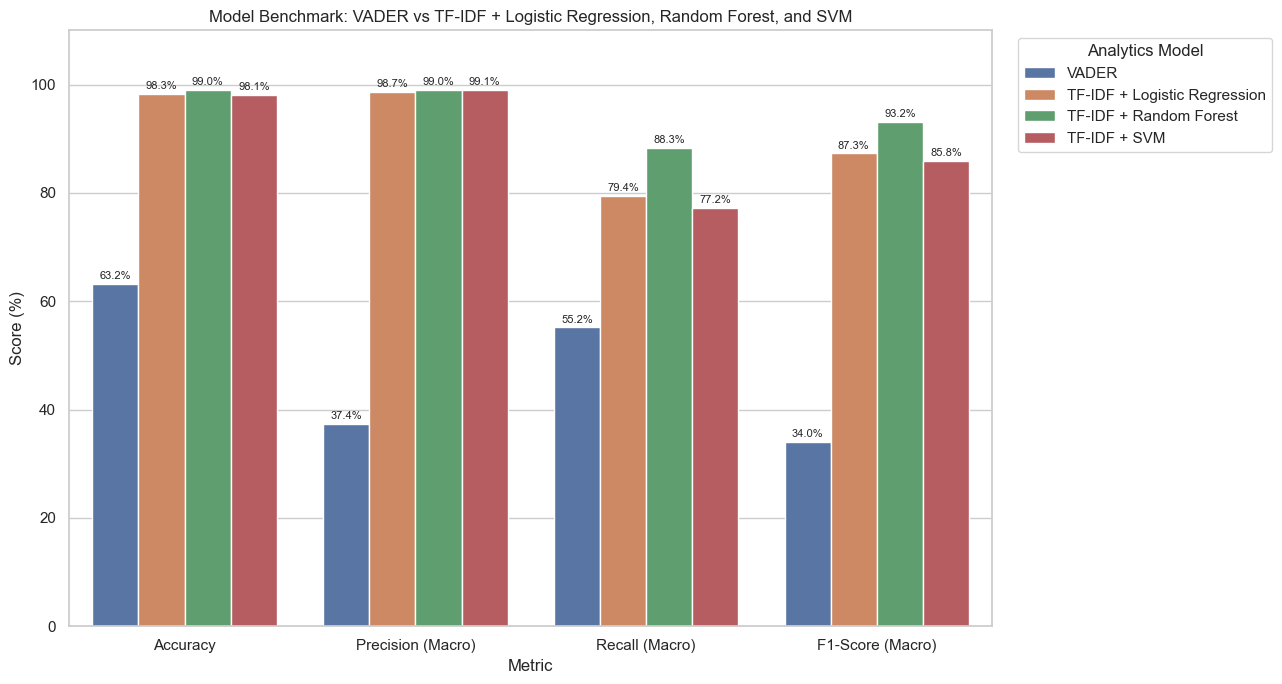

In [51]:
# --- W9 Step 4B: Compare TF-IDF Classifiers ---

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support

logreg_model_w9 = LogisticRegression(max_iter=2000, random_state=42)
logreg_model_w9.fit(X_train_tfidf, y_train)
logreg_predictions_w9 = logreg_model_w9.predict(X_test_tfidf)

rf_model_w9 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model_w9.fit(X_train_tfidf, y_train)
rf_predictions_w9 = rf_model_w9.predict(X_test_tfidf)

model_predictions_w9 = {
    'VADER': vader_predictions_w9,
    'TF-IDF + Logistic Regression': logreg_predictions_w9,
    'TF-IDF + Random Forest': rf_predictions_w9,
    'TF-IDF + SVM': svm_predictions_w9,
}

comparison_rows_w9 = []
for model_name, predictions in model_predictions_w9.items():
    print(f'{model_name} Classification Report')
    print(classification_report(y_test, predictions, target_names=class_names_w9, labels=[0, 1, 2], zero_division=0))

    precision_w9, recall_w9, f1_w9, _ = precision_recall_fscore_support(
        y_test,
        predictions,
        average='macro',
        zero_division=0
    )
    comparison_rows_w9.extend([
        {'Metric': 'Accuracy', 'Score (%)': accuracy_score(y_test, predictions) * 100, 'Analytics Model': model_name},
        {'Metric': 'Precision (Macro)', 'Score (%)': precision_w9 * 100, 'Analytics Model': model_name},
        {'Metric': 'Recall (Macro)', 'Score (%)': recall_w9 * 100, 'Analytics Model': model_name},
        {'Metric': 'F1-Score (Macro)', 'Score (%)': f1_w9 * 100, 'Analytics Model': model_name},
    ])

df_model_compare_w9 = pd.DataFrame(comparison_rows_w9)
display(df_model_compare_w9.pivot(index='Analytics Model', columns='Metric', values='Score (%)').round(2))

plt.figure(figsize=(13, 7))
sns.set_theme(style='whitegrid')
ax = sns.barplot(data=df_model_compare_w9, x='Metric', y='Score (%)', hue='Analytics Model')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)
plt.title('Model Benchmark: VADER vs TF-IDF + Logistic Regression, Random Forest, and SVM')
plt.ylabel('Score (%)')
plt.ylim(0, 110)
plt.legend(title='Analytics Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Sentence-Level Analysis and Export Pipeline

The final W9 workflow breaks a full tweet into sentences, scores them individually with VADER, and exports the sentence-level results into JSON and CSV files.


In [52]:
# --- W9 Step 5: Sentence-Level Polarity and Serialization ---

from nltk.tokenize import sent_tokenize

multi_sentence_rows = df_w9[df_w9['TWEET'].str.count(r'[.!?]') >= 1]
sample_row = multi_sentence_rows.iloc[0] if not multi_sentence_rows.empty else df_w9.iloc[0]
raw_text_block = sample_row['TWEET']
author_profile = sample_row['STOCK']

print(f'Sentence-level analysis sample for {author_profile}:')
print(raw_text_block)
print()

individual_sentences = sent_tokenize(raw_text_block)
for index, sentence_string in enumerate(individual_sentences, start=1):
    compound_score = sia_w9.polarity_scores(sentence_string)['compound']
    if compound_score >= 0.05:
        tone = 'POSITIVE'
    elif compound_score <= -0.05:
        tone = 'NEGATIVE'
    else:
        tone = 'NEUTRAL'
    print(f'Sentence #{index}: [Tone: {tone} | Score: {compound_score:+.4f}] -> {sentence_string}')

structured_sentiment_objects = []
export_rows = df_w9.head(50).copy()
for row_idx, row in export_rows.iterrows():
    sentences_list = sent_tokenize(str(row['TWEET']))
    for sentence_idx, sentence_str in enumerate(sentences_list):
        score = sia_w9.polarity_scores(sentence_str)['compound']
        structured_sentiment_objects.append({
            'record_index': int(row_idx),
            'stock': str(row['STOCK']),
            'sentence_id': int(sentence_idx),
            'sentence_text': str(sentence_str),
            'vader_compound_score': float(score)
        })

json_output_path = 'covid_sentence_sentiments.json'
with open(json_output_path, 'w', encoding='utf-8') as json_file:
    json.dump(structured_sentiment_objects, json_file, indent=4, ensure_ascii=False)

df_output_csv = pd.DataFrame(structured_sentiment_objects)
csv_output_path = 'covid_sentence_sentiments.csv'
df_output_csv.to_csv(csv_output_path, index=False)

print()
print('Sentence-level export complete:')
print(f'JSON: {json_output_path}')
print(f'CSV:  {csv_output_path}')


Sentence-level analysis sample for Nike:
RT @stardazzledd: Nike Windbreakers 💝

Shop: https://t.co/kgR2Ik4jFR

Free Shipping Worldwide 💕 https://t.co/aGAqU7AnXM

Sentence #1: [Tone: POSITIVE | Score: +0.5106] -> RT @stardazzledd: Nike Windbreakers 💝

Shop: https://t.co/kgR2Ik4jFR

Free Shipping Worldwide 💕 https://t.co/aGAqU7AnXM

Sentence-level export complete:
JSON: covid_sentence_sentiments.json
CSV:  covid_sentence_sentiments.csv
